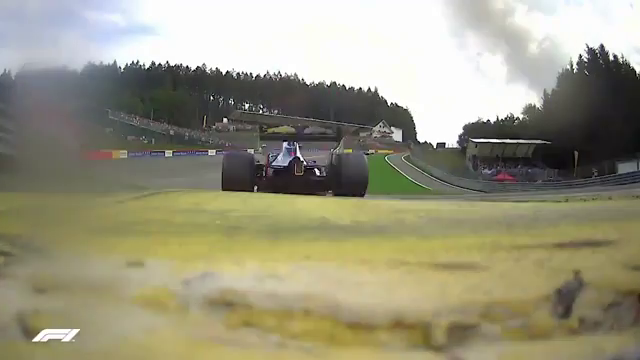

KeyboardInterrupt: 

In [ ]:
import cv2
import random
from ultralytics import YOLO
from IPython.display import display, clear_output
from PIL import Image
import numpy as np
import io

# Load class list
with open(r"C:\Users\anish\Desktop\coco.txt", "r") as my_file:
    class_list = my_file.read().strip().split("\n")

# Generate random colors
detection_color = [(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for _ in class_list]

# Load YOLOv8 model
model = YOLO(r"C:\Users\anish\Downloads\yolov8n.pt")

# Open video file
cap = cv2.VideoCapture(r"C:\Users\anish\Downloads\3664620029-preview.mp4")

if not cap.isOpened():
    print("Error: Could not open video.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Video ended or frame read error.")
            break

        results = model.predict(source=frame, conf=0.45, save=False)
        boxes = results[0].boxes

        for box in boxes:
            clsID = int(box.cls.cpu().numpy()[0])
            conf = box.conf.cpu().numpy()[0]
            bb = box.xyxy.cpu().numpy()[0]

            cv2.rectangle(
                frame,
                (int(bb[0]), int(bb[1])),
                (int(bb[2]), int(bb[3])),
                detection_color[clsID],
                2
            )

            label = f'{class_list[clsID]} {round(conf * 100, 2)}%'
            cv2.putText(
                frame,
                label,
                (int(bb[0]), int(bb[1]) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2
            )

        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Display the frame
        clear_output(wait=True)
        display(Image.fromarray(frame_rgb))
